In [1]:
import re
import glob
from pathlib import Path
from datetime import datetime

import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ---- User-adjustable roots ----
LEFT_ROOT  = Path("DIST-HLS/alert/Lodging")  # downloaded HLS ALERT assets
RIGHT_ROOT = Path("runs_dist_s1")           # base directory for DIST-S1 runs

# Model/run folders to consider (subdirs under each case directory)
RIGHT_VARIANTS = [
    "chile_transformer_anni_10",
    "chile_transformer_anni_20",
    "chile_transformer_anni_20_diego_4",
    "chile_transformer_anni_20_diego_8",
    "chile_transformer_optimized",
    "chile_transformer_optimized_fine",
]

LEFT_REQUIRE_STATUS = True   # only use *STATUS.tif on left
SAVE_PNG = False             # set True to save figures alongside data

# ---- Helpers ----
tile_re = re.compile(r"(T\d{2}[A-Z]{3})")
date8_re = re.compile(r"_(\d{8})T")  # e.g., ..._20250624T092355Z...

def parse_tile_and_date8_from_name(name: str):
    """Return (tile, yyyymmdd) or (None, None) if not found."""
    t = tile_re.search(name)
    d = date8_re.search(name)
    tile = t.group(1) if t else None
    date8 = d.group(1) if d else None
    return tile, date8

def yyyymmdd_to_dash(yyyymmdd: str):
    return f"{yyyymmdd[:4]}-{yyyymmdd[4:6]}-{yyyymmdd[6:8]}"

def read_raster_and_cmap(path):
    """Read band-1 array, profile, nodata, and a matplotlib ListedColormap if present."""
    with rasterio.open(path) as ds:
        arr = ds.read(1)
        profile = ds.profile
        nodata = ds.nodata
        # Build matplotlib ListedColormap from rasterio colormap if available
        cmap = None
        try:
            cm = ds.colormap(1)  # dict: {val: (r,g,b,a)} in 0-255
            if cm:
                max_key = max(cm.keys())
                size = max(256, max_key + 1)  # ensure enough entries
                colors = np.zeros((size, 4), dtype=float)
                for k, rgba in cm.items():
                    r, g, b, a = rgba
                    colors[k] = [r/255.0, g/255.0, b/255.0, a/255.0]
                cmap = ListedColormap(colors, name=f"cmap_{Path(path).stem}")
                # If nodata specified, make "bad" transparent; also try to set nodata color transparent
                cmap.set_bad((0, 0, 0, 0))
                if nodata is not None and 0 <= int(nodata) < colors.shape[0]:
                    colors[int(nodata), 3] = 0.0
                    cmap = ListedColormap(colors, name=f"cmap_{Path(path).stem}")
        except Exception:
            cmap = None
    return arr, profile, nodata, cmap

def reproject_to_match(src_arr, src_prof, dst_prof, src_nodata=None, dst_nodata=None):
    """Reproject src to match dst profile (crs, transform, width, height)."""
    out = np.full((dst_prof["height"], dst_prof["width"]), dst_nodata if dst_nodata is not None else 0, dtype=src_arr.dtype)
    reproject(
        source=src_arr,
        destination=out,
        src_transform=src_prof["transform"],
        src_crs=src_prof["crs"],
        dst_transform=dst_prof["transform"],
        dst_crs=dst_prof["crs"],
        resampling=Resampling.nearest,
        src_nodata=src_nodata,
        dst_nodata=dst_nodata,
        num_threads=1,
    )
    return out

def format_date_from_name(name: str):
    """Extract yyyymmdd -> yyyy-mm-dd if present; else return 'unknown'."""
    _, d8 = parse_tile_and_date8_from_name(name)
    return yyyymmdd_to_dash(d8) if d8 else "unknown"


In [4]:
case_name = "New construction"


[INFO] Using raster center for 18SUH @ 2024-12-31: lat=38.342352, lon=-76.660193
[INFO] No right-side matches for tile=18SUH, HLS date=2024-12-31
[(38.89944199257163, -76.72312133749506, 1)]


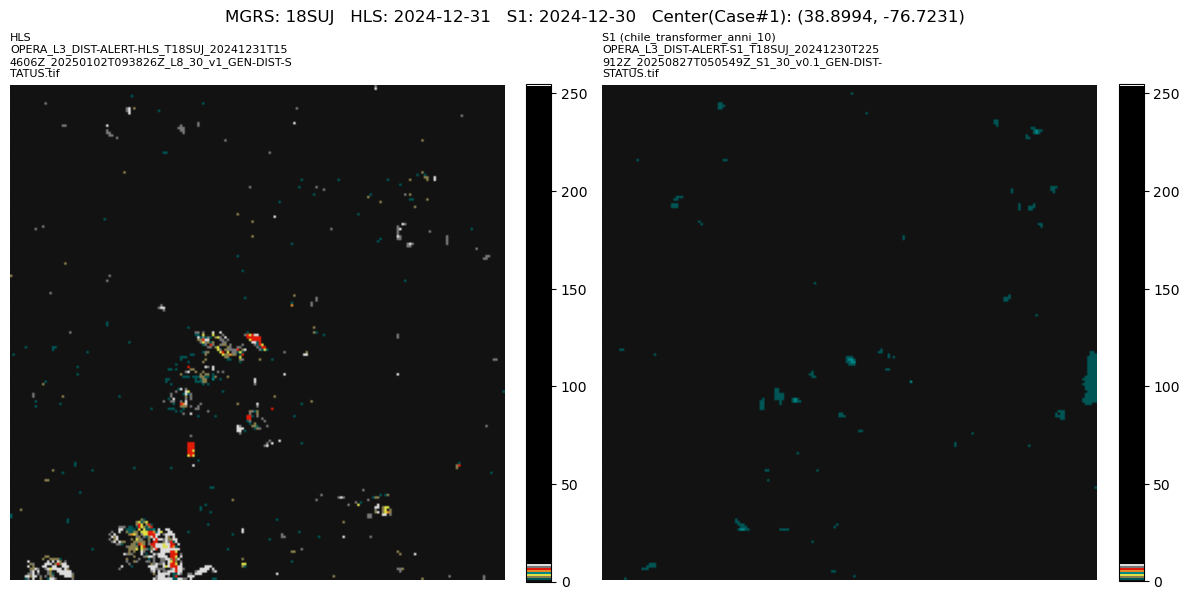

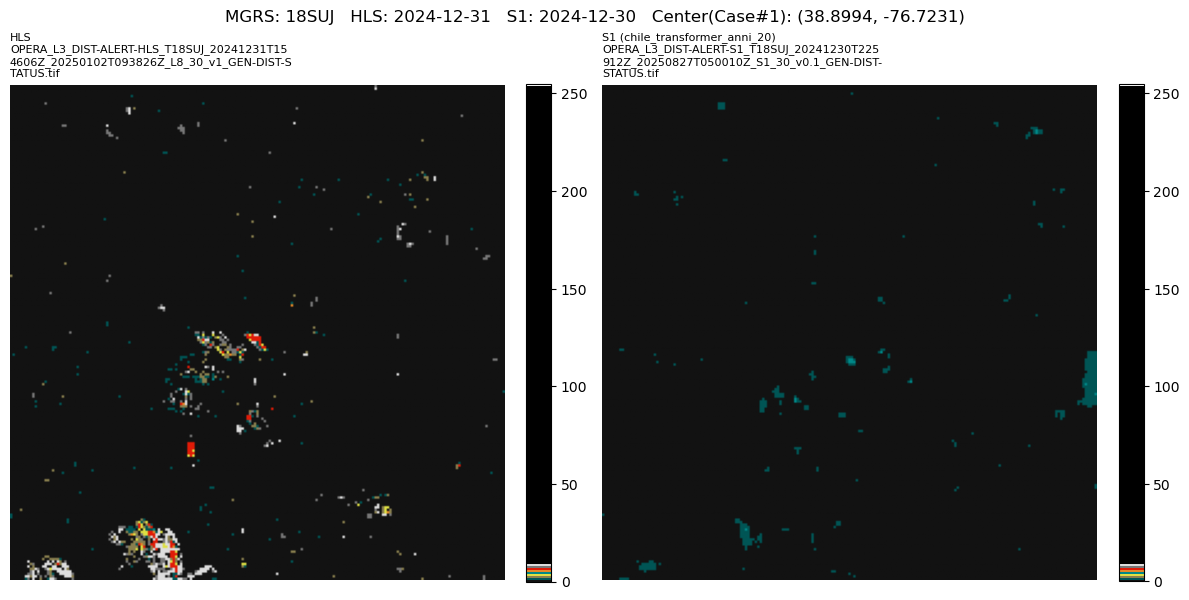

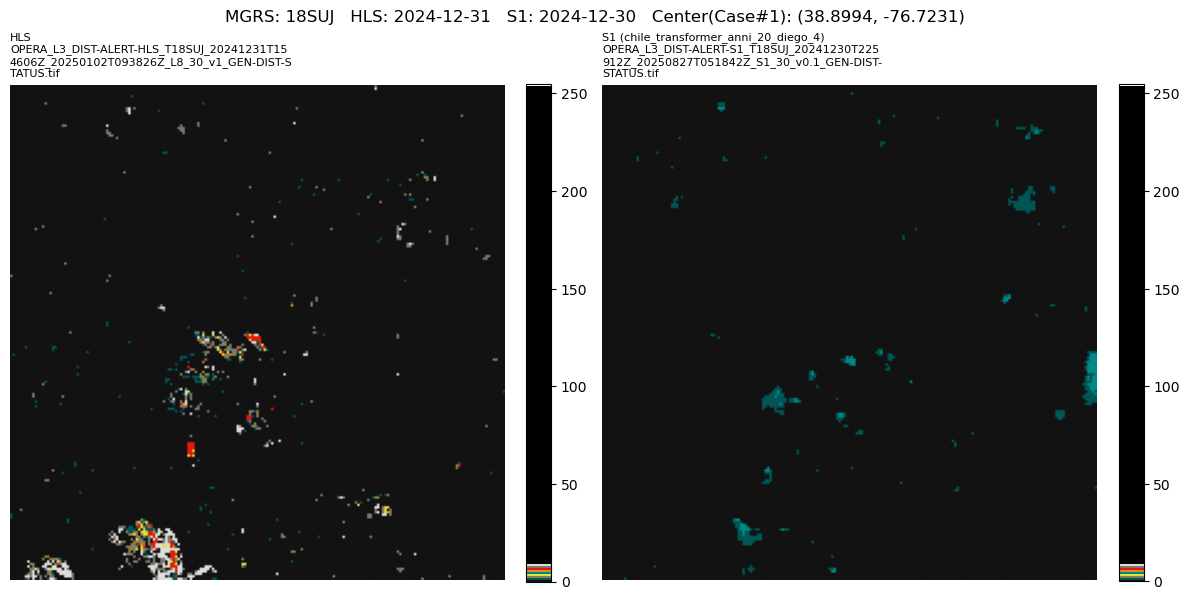

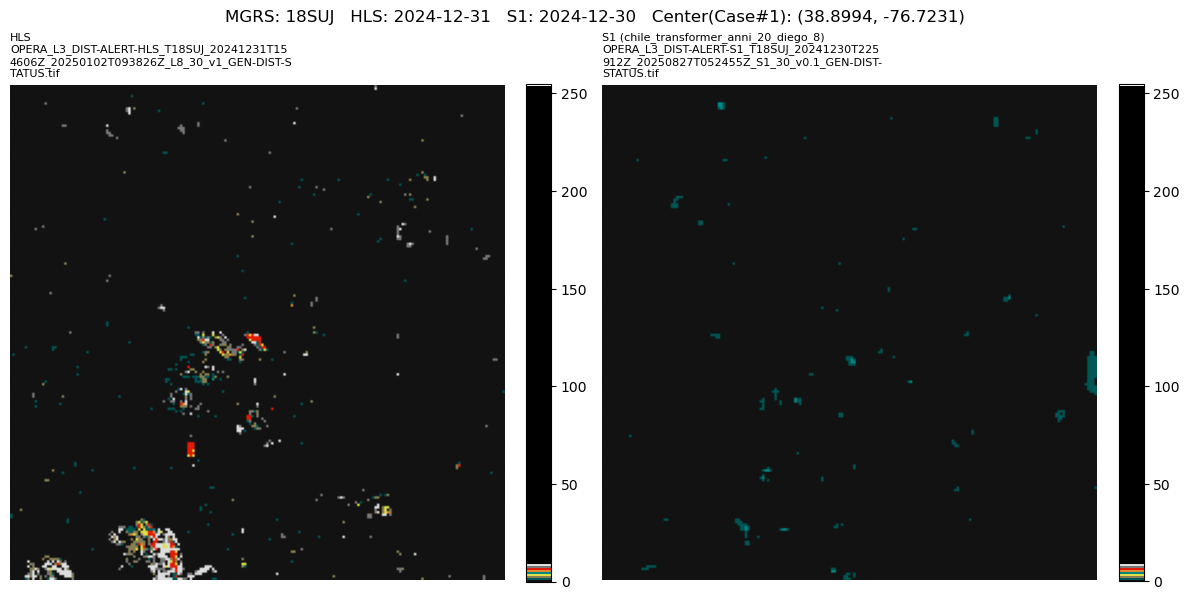

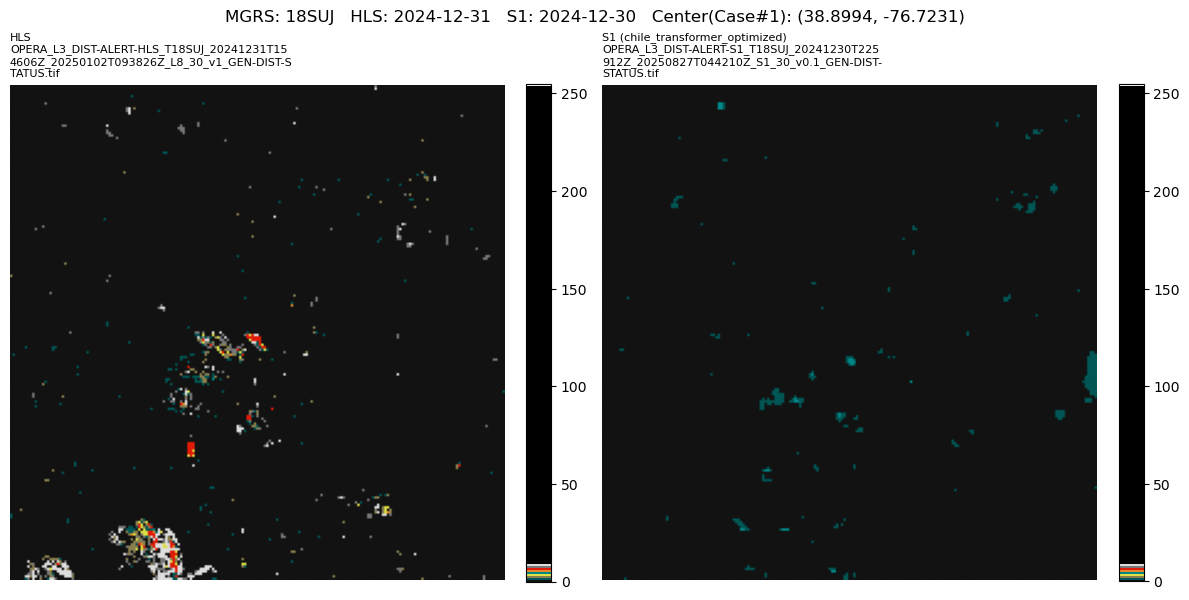

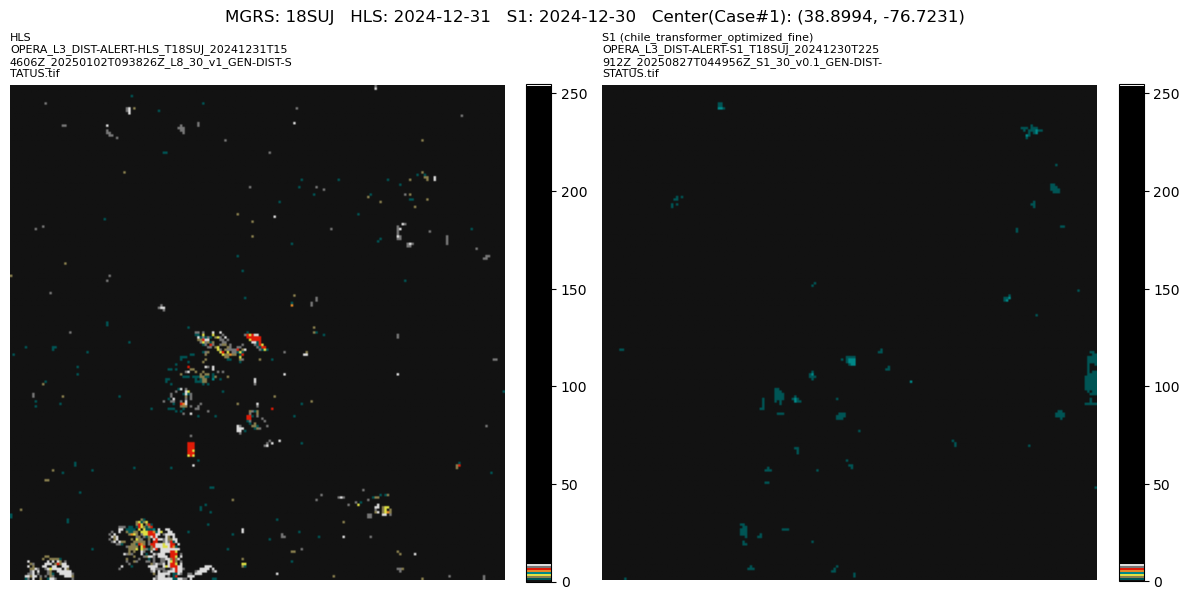

In [6]:


import re
import math
import glob
from pathlib import Path
from textwrap import fill

import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling, transform as rio_transform
from rasterio.transform import rowcol
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# -------------------- Provided cases --------------------
cases = {
  "Mining": [
    {"lat": -5.773196381012654, "lon": -56.806566069338245, "date": "2025-06-29"},
    {"lat": -12.9890141517277,  "lon": -70.06357428871692, "date": "2025-04-18"},
    {"lat":  2.0185043672215914, "lon":  29.773492831188207, "date": "2024-12-02"},
    {"lat":  0.5632783027227907, "lon": 127.91000858625176, "date": "2024-10-06"},
  ],
    "Logging": [
    {"lat": -7.614112272029289,  "lon":  -75.40825653555396, "date": "2024-09-06"},
    {"lat":  2.974193399509278,  "lon":   17.879592039849456, "date": "2025-02-28"},
    {"lat": 46.126040790060436,  "lon": -122.42122283481473, "date": "2024-11-30"},
    {"lat": 61.522819402112866,  "lon":   15.973959187506068, "date": "2025-05-15"},
  ],
    "Road expansion": [
    {"lat": 35.42336004982615, "lon": 119.40456071405788, "date": "2025-04-30"},
    {"lat": 34.90684358345317, "lon": 115.46110157851172, "date": "2025-04-13"},
  ],
  "New construction": [
    {"lat": 38.89944199257163, "lon": -76.72312133749506, "date": "2024-12-31"},
  ],
}

# -------------------- Prepare cases --------------------
case_points = [{"group": case_name, "idx": i+1, **c} for i, c in enumerate(cases.get(case_name, []))]
# -------------------- Roots / settings --------------------
LEFT_ROOT  = Path(f"DIST-HLS/alert/{case_name}")
RIGHT_ROOT = Path("runs_dist_s1")

RIGHT_VARIANTS = [
    "chile_transformer_anni_10",
    "chile_transformer_anni_20",
    "chile_transformer_anni_20_diego_4",
    "chile_transformer_anni_20_diego_8",
    "chile_transformer_optimized",
    "chile_transformer_optimized_fine",
]

LEFT_REQUIRE_STATUS = True
SAVE_PNG = False
RADIUS_KM = 3.0

# -------------------- Helpers --------------------
tile_re  = re.compile(r"(T\d{2}[A-Z]{3})")
date8_re = re.compile(r"_(\d{8})T")

def parse_tile_and_date8_from_name(name: str):
    t = tile_re.search(name)
    d = date8_re.search(name)
    tile = t.group(1) if t else None
    date8 = d.group(1) if d else None
    return tile, date8

def yyyymmdd_to_dash(yyyymmdd: str):
    return f"{yyyymmdd[:4]}-{yyyymmdd[4:6]}-{yyyymmdd[6:8]}"

def read_raster_and_cmap(path):
    with rasterio.open(path) as ds:
        arr = ds.read(1)
        profile = ds.profile
        nodata = ds.nodata
        cmap = None
        try:
            cm = ds.colormap(1)
            if cm:
                max_key = max(cm.keys())
                size = max(256, max_key + 1)
                colors = np.zeros((size, 4), dtype=float)
                for k, rgba in cm.items():
                    r, g, b, a = rgba
                    colors[k] = [r/255.0, g/255.0, b/255.0, a/255.0]
                if nodata is not None and 0 <= int(nodata) < size:
                    colors[int(nodata), 3] = 0.0
                cmap = ListedColormap(colors, name=f"cmap_{Path(path).stem}")
                cmap.set_bad((0, 0, 0, 0))
        except Exception:
            cmap = None
    return arr, profile, nodata, cmap

def reproject_to_match(src_arr, src_prof, dst_prof, src_nodata=None, dst_nodata=None):
    out = np.full((dst_prof["height"], dst_prof["width"]), dst_nodata if dst_nodata is not None else 0, dtype=src_arr.dtype)
    reproject(
        source=src_arr,
        destination=out,
        src_transform=src_prof["transform"],
        src_crs=src_prof["crs"],
        dst_transform=dst_prof["transform"],
        dst_crs=dst_prof["crs"],
        resampling=Resampling.nearest,
        src_nodata=src_nodata,
        dst_nodata=dst_nodata,
        num_threads=1,
    )
    return out

def contains_latlon(profile, lat, lon):
    x, y = rio_transform("EPSG:4326", profile["crs"], [lon], [lat])
    x, y = x[0], y[0]
    try:
        r, c = rowcol(profile["transform"], x, y)
    except Exception:
        return False
    return (0 <= r < profile["height"]) and (0 <= c < profile["width"])

def window_from_center_latlon(profile, lat, lon, radius_km=10.0):
    crs = profile["crs"]
    transform = profile["transform"]
    height, width = profile["height"], profile["width"]

    x0, y0 = rio_transform("EPSG:4326", crs, [lon], [lat])
    x0, y0 = x0[0], y0[0]

    if hasattr(crs, "is_projected") and crs.is_projected:
        radius_m = radius_km * 1000.0
        xmin, xmax = x0 - radius_m, x0 + radius_m
        ymin, ymax = y0 - radius_m, y0 + radius_m
    else:
        deg_lat = radius_km / 111.0
        deg_lon = radius_km / (111.320 * max(np.cos(np.radians(lat)), 1e-6))
        lon_min, lon_max = lon - deg_lon, lon + deg_lon
        lat_min, lat_max = lat - deg_lat, lat + deg_lat
        xs, ys = rio_transform("EPSG:4326", crs,
                               [lon_min, lon_max, lon_min, lon_max],
                               [lat_min, lat_min, lat_max, lat_max])
        xmin, xmax = min(xs), max(xs)
        ymin, ymax = min(ys), max(ys)

    r1, c1 = rowcol(transform, xmin, ymax, op=math.floor)
    r2, c2 = rowcol(transform, xmax, ymin, op=math.ceil)

    row_start = max(0, min(r1, r2))
    row_stop  = min(height, max(r1, r2))
    col_start = max(0, min(c1, c2))
    col_stop  = min(width, max(c1, c2))

    if row_stop <= row_start or col_stop <= col_start:
        return slice(0, height), slice(0, width)

    return slice(row_start, row_stop), slice(col_start, col_stop)

def format_date_from_name(name: str):
    _, d8 = parse_tile_and_date8_from_name(name)
    return yyyymmdd_to_dash(d8) if d8 else "unknown"

def find_variant_in_path(path: Path, variants):
    for v in variants:
        if v in path.parts:
            return v
    return "unknown"

def vlabel(title, filename, variant=None, width=48):
    """Build a vertical (multi-line) label with optional variant name."""
    head = f"{title}" if variant in (None, "unknown") else f"{title} ({variant})"
    return head + "\n" + fill(str(filename), width=width, break_long_words=True, break_on_hyphens=False)



# -------------------- Gather left (HLS) candidates --------------------
left_tifs = sorted(LEFT_ROOT.rglob("*.tif"))
if LEFT_REQUIRE_STATUS:
    left_tifs = [p for p in left_tifs if "GEN-DIST-STATUS" in p.name.upper()]

if not left_tifs:
    print(f"No left-side GeoTIFFs found under {LEFT_ROOT} (STATUS filter={LEFT_REQUIRE_STATUS}).")

pairs_found = 0

for left_path in left_tifs:
    left_tile_full, left_d8 = parse_tile_and_date8_from_name(left_path.name)
    if not (left_tile_full and left_d8):
        print(f"[SKIP] Could not parse tile/date from left: {left_path.name}")
        continue

    left_tile = left_tile_full[1:]  # drop 'T'
    left_date = yyyymmdd_to_dash(left_d8)

    left_arr, left_prof, left_nodata, left_cmap = read_raster_and_cmap(left_path)
    if left_nodata is not None:
        left_arr = np.ma.masked_equal(left_arr, left_nodata)

    # centers: case points with same date & inside raster (else fallback to raster center)
    centers = []
    for cp in case_points:
        if cp["date"] != left_date:
            continue
        if contains_latlon(left_prof, cp["lat"], cp["lon"]):
            centers.append((cp["lat"], cp["lon"], cp["idx"]))
            print(centers)
    if not centers:
        with rasterio.open(left_path) as ds:
            center_row, center_col = ds.height // 2, ds.width // 2
            x_center, y_center = ds.transform * (center_col + 0.5, center_row + 0.5)
            lon_c, lat_c = rio_transform(ds.crs, "EPSG:4326", [x_center], [y_center])
            centers = [(lat_c[0], lon_c[0], 0)]
        print(f"[INFO] Using raster center for {left_tile} @ {left_date}: lat={centers[0][0]:.6f}, lon={centers[0][1]:.6f}")

    # find right-side candidates
    right_globs = [str(RIGHT_ROOT / f"**/*_{left_tile}_*_*/{variant}/*/*DIST-STATUS.tif") for variant in RIGHT_VARIANTS]
    right_hits = []
    for pat in right_globs:
        right_hits.extend(glob.glob(pat, recursive=True))

    if not right_hits:
        print(f"[INFO] No right-side matches for tile={left_tile}, HLS date={left_date}")
        continue

    for right_path in sorted(set(map(Path, right_hits))):
        right_arr, right_prof, right_nodata, right_cmap = read_raster_and_cmap(right_path)

        need_reproj = (
            (right_prof["crs"] != left_prof["crs"]) or
            (right_prof["transform"] != left_prof["transform"]) or
            (right_prof["width"] != left_prof["width"]) or
            (right_prof["height"] != left_prof["height"])
        )
        if need_reproj:
            right_arr_on_left = reproject_to_match(
                right_arr, right_prof, left_prof,
                src_nodata=right_nodata, dst_nodata=left_nodata
            )
        else:
            right_arr_on_left = right_arr

        if left_nodata is not None:
            right_arr_on_left = np.ma.masked_equal(right_arr_on_left, left_nodata)

        variant_name = find_variant_in_path(right_path, RIGHT_VARIANTS)
        s1_date = format_date_from_name(right_path.name)

        for lat0, lon0, idx in centers:
            row_sl, col_sl = window_from_center_latlon(left_prof, lat0, lon0, RADIUS_KM)
            left_crop  = left_arr[row_sl, col_sl]
            right_crop = right_arr_on_left[row_sl, col_sl]

            title_top = f"MGRS: {left_tile}   HLS: {left_date}   S1: {s1_date}   Center({'Case#'+str(idx) if idx else 'Center'}): ({lat0:.4f}, {lon0:.4f})"

            fig = plt.figure(figsize=(12, 6))
            ax1 = fig.add_subplot(1, 2, 1)
            ax2 = fig.add_subplot(1, 2, 2)

            # LEFT
            if left_cmap is not None:
                im1 = ax1.imshow(left_crop, cmap=left_cmap, vmin=0, vmax=left_cmap.N - 1)
            else:
                im1 = ax1.imshow(left_crop)
            ax1.set_title(vlabel("HLS", left_path.name, variant=None, width=42), fontsize=8, loc="left")
            ax1.axis("off")
            fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

            # RIGHT
            if right_cmap is not None:
                im2 = ax2.imshow(right_crop, cmap=right_cmap, vmin=0, vmax=right_cmap.N - 1)
            else:
                im2 = ax2.imshow(right_crop)
            ax2.set_title(vlabel("S1", right_path.name, variant=variant_name, width=42), fontsize=8, loc="left")
            ax2.axis("off")
            fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

            fig.suptitle(title_top, fontsize=12, y=1)
            fig.tight_layout()

            if SAVE_PNG:
                out_png = left_path.parent / f"compare_zoom_{left_tile}_{left_date}_case{idx}_{variant_name}_{right_path.stem}.png"
                fig.savefig(out_png, dpi=150, bbox_inches="tight")

            plt.show()
            pairs_found += 1

if pairs_found == 0:
    print("No visualization pairs were produced. Check roots/patterns or make sure case dates intersect HLS dates.")
